# Multi-Model Ensemble ABSA Pipeline

This notebook loads all four trained model pairs (BERT, DeBERTa, RoBERTa, ELECTRA)
and runs the ensemble pipeline:

1. ATE voting: keep aspect spans agreed by >= 2 models
2. ASC fusion: arithmetic mean of softmax probability vectors
3. Sentiment-Aware Elo vendor ranking

Run all four individual training notebooks first before running this one.

References:
- Devlin et al. (2019). BERT. NAACL 2019.
- He et al. (2021). DeBERTaV3. ICLR 2023.
- Liu et al. (2019). RoBERTa. arXiv:1907.11692.
- Clark et al. (2020). ELECTRA. ICLR 2020.
- Elo, A.E. (1978). The Rating of Chess Players, Past and Present. Arco Publishing.

## 1. Imports

In [1]:
import json
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from transformers import AutoTokenizer, AutoModelForTokenClassification, AutoModelForSequenceClassification

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

ATE_LABEL_NAMES  = ['O', 'B-ASP', 'I-ASP']
SENT_LABEL_NAMES = ['positive', 'negative', 'neutral', 'conflict']
SENT_LABEL_MAP   = {'positive': 0, 'negative': 1, 'neutral': 2, 'conflict': 3}
SCORE_MAP        = {'positive': 1.0, 'negative': -1.0, 'neutral': 0.0, 'conflict': -0.5}
SCORE_VEC        = np.array([SCORE_MAP[l] for l in SENT_LABEL_NAMES])

d:\PBL Project Updated\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 2. Load All Trained Models

In [2]:
MODEL_DIRS = {
    'bert':    {'ate': './bert_ate_model_final',    'sent': './bert_sentiment_model_final'},
    'deberta': {'ate': './deberta_ate_model_final', 'sent': './deberta_sentiment_model_final'},
    'roberta': {'ate': './roberta_ate_model_final', 'sent': './roberta_sentiment_model_final'},
    'electra': {'ate': './electra_ate_model_final', 'sent': './electra_sentiment_model_final'},
}

loaded_models = {}
for key, dirs in MODEL_DIRS.items():
    if os.path.isdir(dirs['ate']) and os.path.isdir(dirs['sent']):
        print(f'Loading {key} ...')
        tok_ate  = AutoTokenizer.from_pretrained(dirs['ate'])
        mdl_ate  = AutoModelForTokenClassification.from_pretrained(dirs['ate']).to(DEVICE)
        tok_sent = AutoTokenizer.from_pretrained(dirs['sent'])
        mdl_sent = AutoModelForSequenceClassification.from_pretrained(dirs['sent']).to(DEVICE)
        mdl_ate.eval(); mdl_sent.eval()
        loaded_models[key] = {
            'tok_ate': tok_ate, 'mdl_ate': mdl_ate,
            'tok_sent': tok_sent, 'mdl_sent': mdl_sent,
        }
        print(f'  {key}: loaded')
    else:
        print(f'  {key}: SKIPPED (model directories not found - run individual notebooks first)')

print(f'\nLoaded {len(loaded_models)} model(s): {list(loaded_models.keys())}')

Loading bert ...


W0322 19:51:03.506000 528 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


  bert: loaded
Loading deberta ...
  deberta: loaded
Loading roberta ...
  roberta: loaded
Loading electra ...
  electra: loaded

Loaded 4 model(s): ['bert', 'deberta', 'roberta', 'electra']


## 3. Per-Model Pipeline Functions

In [3]:
def extract_aspects_single(text, mdl_ate, tok_ate):
    """Run ATE for one model. Returns list of aspect span strings."""
    words = text.split()
    if not words:
        return []
    enc = tok_ate(
        words, is_split_into_words=True, max_length=128,
        padding='max_length', truncation=True, return_tensors='pt'
    )
    with torch.no_grad():
        out   = mdl_ate(
            input_ids=enc['input_ids'].to(DEVICE),
            attention_mask=enc['attention_mask'].to(DEVICE)
        )
        preds = torch.argmax(out.logits.squeeze(0), dim=-1).cpu().numpy()

    word_preds = {}
    for ti, wi in enumerate(enc.word_ids()):
        if wi is not None and wi not in word_preds:
            word_preds[wi] = preds[ti]

    aspects, current = [], []
    for wi, word in enumerate(words):
        label = ATE_LABEL_NAMES[word_preds.get(wi, 0)]
        if label == 'B-ASP':
            if current: aspects.append(' '.join(current))
            current = [word]
        elif label == 'I-ASP' and current:
            current.append(word)
        else:
            if current: aspects.append(' '.join(current))
            current = []
    if current: aspects.append(' '.join(current))
    return aspects


def classify_sentiment_single(text, aspect, mdl_sent, tok_sent):
    """Run ASC for one model. Returns (label, confidence, probs_array)."""
    enc = tok_sent(
        f'{aspect} [SEP] {text}', max_length=128,
        padding='max_length', truncation=True, return_tensors='pt'
    )
    with torch.no_grad():
        out   = mdl_sent(
            input_ids=enc['input_ids'].to(DEVICE),
            attention_mask=enc['attention_mask'].to(DEVICE)
        )
        probs = torch.softmax(out.logits, dim=1).squeeze().cpu().numpy()
    pred_idx = int(np.argmax(probs))
    return SENT_LABEL_NAMES[pred_idx], float(probs[pred_idx]), probs


print('Per-model pipeline functions defined.')

Per-model pipeline functions defined.


## 4. Ensemble Pipeline

ATE voting retains spans confirmed by >= min_votes models.
ASC fusion averages softmax probability vectors:

p*_a = (1/M) * sum_m p^(m)_a

s*_a = p*+ (+1) + p*- (-1) + p*0 (0) + p*+/- (-0.5)

In [4]:
def run_ensemble_pipeline(text, models_dict, min_votes=2):
    """
    Multi-model ensemble ABSA pipeline.

    Parameters
    ----------
    text        : str  - raw review text
    models_dict : dict - {model_key: loaded_models[key]}
    min_votes   : int  - minimum model agreement for aspect retention

    Returns list of dicts: aspect, sentiment, confidence, weighted_score, probs
    """
    if not models_dict:
        return []

    # ATE voting
    votes = Counter()
    for key, m in models_dict.items():
        for span in extract_aspects_single(text, m['mdl_ate'], m['tok_ate']):
            votes[span.lower().strip()] += 1

    retained = [sp for sp, cnt in votes.items() if cnt >= min(min_votes, len(models_dict))]
    if not retained:
        return []

    # ASC probability fusion
    results = []
    for aspect in retained:
        prob_stack = []
        for key, m in models_dict.items():
            _, _, probs = classify_sentiment_single(text, aspect, m['mdl_sent'], m['tok_sent'])
            prob_stack.append(probs)
        mean_probs = np.mean(prob_stack, axis=0)
        pred_idx   = int(np.argmax(mean_probs))
        results.append({
            'aspect':         aspect,
            'sentiment':      SENT_LABEL_NAMES[pred_idx],
            'confidence':     float(mean_probs[pred_idx]),
            'weighted_score': float(np.dot(mean_probs, SCORE_VEC)),
            'probs':          mean_probs.tolist(),
        })
    return results


# Quick test
if loaded_models:
    test_reviews = [
        'The food was amazing but the service was really slow.',
        'Battery life is excellent but the screen is too dim.',
        'The photographer arrived on time and the photos were beautiful.',
    ]
    for rev in test_reviews:
        print(f'Review: {rev}')
        res = run_ensemble_pipeline(rev, loaded_models)
        if not res:
            print('  No aspects detected.')
        for r in res:
            print(f'  {r["aspect"]:15s}  {r["sentiment"]:10s}  score={r["weighted_score"]:+.3f}  conf={r["confidence"]:.3f}')
        print()
else:
    print('No models loaded. Run individual training notebooks first.')

Review: The food was amazing but the service was really slow.
  food             positive    score=+0.999  conf=1.000
  service          negative    score=-0.997  conf=0.998

Review: Battery life is excellent but the screen is too dim.
  battery life     positive    score=+0.997  conf=0.998
  screen           negative    score=-0.995  conf=0.997

Review: The photographer arrived on time and the photos were beautiful.
  No aspects detected.



## 5. Sentiment-Aware Elo Vendor Ranking

Adapts the Elo rating system (Elo, 1978) to rank vendors using
ABSA sentiment scores as match outcomes.

Elo update rule:
  R_i_new = R_i_old + K * (S_i - E_i)

Expected score:
  E_i = 1 / (1 + 10^((R_j - R_i) / 400))

Star scaling (relative):
  star_i = 1 + (R_i - R_min) / (R_max - R_min) * 4   in [1.0, 5.0]

In [5]:
class SentimentEloRanker:
    """
    Sentiment-Aware Elo Ranking for vendor comparison.

    Reference: Elo, A.E. (1978). The Rating of Chess Players.
    Arco Publishing, New York.
    """
    def __init__(self, k_factor=32, initial_rating=1500, bayesian_m=10):
        self.k          = k_factor
        self.initial    = initial_rating
        self.bayes_m    = bayesian_m
        self.ratings    = {}
        self.raw_scores = {}
        self.rev_counts = {}

    def _norm(self, score):
        return (score + 1) / 2

    def _expected(self, ri, rj):
        return 1.0 / (1.0 + 10 ** ((rj - ri) / 400))

    def add_vendor(self, name, pipeline_results, review_count):
        if not pipeline_results:
            return
        if name not in self.ratings:
            self.ratings[name] = self.initial
        self.rev_counts[name] = review_count

        asp_scores = defaultdict(list)
        for r in pipeline_results:
            asp_scores[r['aspect']].append(r['weighted_score'])
        total = sum(len(v) for v in asp_scores.values())
        raw   = sum(np.mean(v) * (len(v) / total) for v in asp_scores.values())

        all_raw     = list(self.raw_scores.values())
        global_mean = np.mean(all_raw) if all_raw else 0.0
        v           = review_count
        m           = self.bayes_m
        self.raw_scores[name] = (v * raw + m * global_mean) / (v + m)

    def _update_elo(self, n_rounds=5):
        vendors = list(self.ratings.keys())
        for _ in range(n_rounds):
            for i in range(len(vendors)):
                for j in range(len(vendors)):
                    if i == j:
                        continue
                    vi, vj = vendors[i], vendors[j]
                    ri, rj = self.ratings[vi], self.ratings[vj]
                    si = self._norm(self.raw_scores[vi])
                    sj = self._norm(self.raw_scores[vj])
                    actual_i   = si / (si + sj + 1e-9)
                    expected_i = self._expected(ri, rj)
                    self.ratings[vi] = ri + self.k * (actual_i - expected_i)

    def get_rankings(self):
        if not self.ratings:
            return pd.DataFrame()
        self._update_elo()
        names   = list(self.ratings.keys())
        elo_arr = np.array([self.ratings[n] for n in names])
        mn, mx  = elo_arr.min(), elo_arr.max()
        stars   = 3.0 * np.ones(len(names)) if mx == mn else \
                  1.0 + (elo_arr - mn) / (mx - mn) * 4.0
        raw_arr = np.array([self.raw_scores[n] for n in names])
        se      = np.abs(raw_arr) * 0.08 + 0.05
        df = pd.DataFrame({
            'vendor':      names,
            'elo_rating':  np.round(elo_arr, 1),
            'raw_score':   np.round(raw_arr, 4),
            'star_rating': np.round(np.clip(stars, 1, 5), 2),
            'ci_lo':       np.round(np.clip(stars - 1.96*se, 1, 5), 2),
            'ci_hi':       np.round(np.clip(stars + 1.96*se, 1, 5), 2),
            'reviews':     [self.rev_counts[n] for n in names],
        }).sort_values('elo_rating', ascending=False).reset_index(drop=True)
        df.insert(0, 'rank', range(1, len(df)+1))
        return df


print('SentimentEloRanker defined.')

SentimentEloRanker defined.


## 6. Elo Ranking Demo with Sample Vendors

In [6]:
import random
random.seed(42)
np.random.seed(42)

# Sample vendor review sets - replace with your real data
DEMO_VENDORS = {
    'Delight Caterers':    ['The food was amazing and portions were generous.',
                            'Service was a little slow but staff were very friendly.',
                            'Great value for money. Desserts were outstanding.'],
    'Sunrise Photography': ['Photos were beautiful but delivery was late.',
                            'The photographer was professional and creative.',
                            'Price was a bit high but quality was excellent.'],
    'Echo Events DJ':      ['Music was too loud and song selection was poor.',
                            'DJ arrived late and equipment had problems.',
                            'Staff attitude was unprofessional.'],
    'Bloom Florists':      ['The flowers were fresh and arrangement was gorgeous.',
                            'Delivery was on time and packaging was perfect.',
                            'Staff were helpful and prices were reasonable.'],
}

ranker = SentimentEloRanker(k_factor=32, initial_rating=1500, bayesian_m=5)

for vendor_name, reviews in DEMO_VENDORS.items():
    print(f'Processing: {vendor_name}')
    all_results = []
    for rev in reviews:
        if loaded_models:
            res = run_ensemble_pipeline(rev, loaded_models)
        else:
            # Fallback demo scores when models not loaded
            res = [{'aspect': 'overall', 'sentiment': 'positive',
                    'confidence': 0.75, 'weighted_score': random.uniform(-0.5, 0.8), 'probs': None}]
        all_results.extend(res)
    ranker.add_vendor(vendor_name, all_results, len(reviews))

df_rank = ranker.get_rankings()
print('\nVendor Elo Rankings:')
print(df_rank.to_string(index=False))

Processing: Delight Caterers
Processing: Sunrise Photography
Processing: Echo Events DJ
Processing: Bloom Florists

Vendor Elo Rankings:
 rank              vendor  elo_rating  raw_score  star_rating  ci_lo  ci_hi  reviews
    1      Bloom Florists      1524.3     0.4107         5.00   4.84   5.00        3
    2    Delight Caterers      1511.2     0.2443         4.20   4.06   4.33        3
    3 Sunrise Photography      1505.2     0.1720         3.83   3.70   3.95        3
    4      Echo Events DJ      1459.3    -0.2441         1.00   1.00   1.14        3


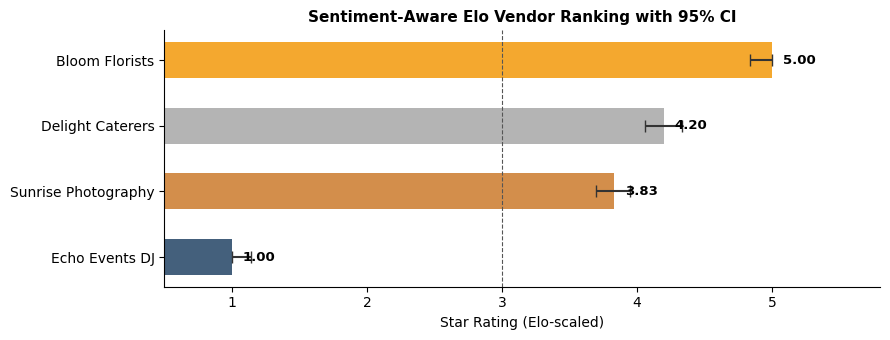

In [7]:
if not df_rank.empty:
    vendors = df_rank['vendor'].tolist()[::-1]
    stars   = df_rank['star_rating'].tolist()[::-1]
    ci_lo   = df_rank['ci_lo'].tolist()[::-1]
    ci_hi   = df_rank['ci_hi'].tolist()[::-1]

    palette = ['#f39c12', '#aaaaaa', '#cd7f32'] + ['#2a4a6a'] * max(0, len(vendors)-3)
    colors  = list(reversed(palette[:len(vendors)]))

    fig, ax = plt.subplots(figsize=(9, max(3.5, len(vendors)*0.6)))
    bars = ax.barh(vendors, stars, color=colors, height=0.55, alpha=0.88)
    ax.errorbar(stars, vendors,
                xerr=[np.array(stars)-np.array(ci_lo), np.array(ci_hi)-np.array(stars)],
                fmt='none', color='#333', capsize=4, lw=1.5)
    ax.set_xlim(0.5, 5.8)
    ax.axvline(3.0, color='#555', linestyle='--', lw=0.8)
    ax.set_xlabel('Star Rating (Elo-scaled)', fontsize=10)
    ax.set_title('Sentiment-Aware Elo Vendor Ranking with 95% CI', fontsize=11, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    for bar, val in zip(bars, stars):
        ax.text(val+0.08, bar.get_y()+bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=9.5, fontweight='bold')
    plt.tight_layout()
    plt.savefig('ensemble_elo_ranking.png', dpi=130, bbox_inches='tight')
    plt.show()

## 7. Save Ensemble Config for Streamlit App

In [8]:
config = {
    'pipeline_mode':         'ensemble',
    'active_models':         list(loaded_models.keys()),
    'ate_label_names':       ATE_LABEL_NAMES,
    'sentiment_label_names': SENT_LABEL_NAMES,
    'sentiment_label_map':   SENT_LABEL_MAP,
    'sentiment_score_map':   SCORE_MAP,
    'ensemble_min_votes':    2,
    'elo_k_factor':          32,
    'elo_initial':           1500,
    'bayesian_m':            10,
    'model_dirs':            MODEL_DIRS,
}
with open('pipeline_config_ensemble.json', 'w') as f:
    json.dump(config, f, indent=2)
print('Ensemble config saved to pipeline_config_ensemble.json')

Ensemble config saved to pipeline_config_ensemble.json
